# NOAA Global Hourly: Glasgow Airport

This example downloads observations for Glasgow Airport (WMO station `03140099999`, ICAO `EGPF`) from NOAA's public Global Hourly API, cleans packed weather fields, and plots temperature and wind speed.

In [ ]:
from models import LSTMForecaster, train_lstm_model

In [2]:
station = '03140099999'
station_name = 'Glasgow Airport (EGPF)'
start_date = '2024-01-01'
end_date = '2024-01-31'

raw = fetch_global_hourly(station, start_date, end_date)
if raw.empty:
    raise RuntimeError('NOAA returned no records. Check the station ID or date range.')

print(f'Downloaded {len(raw):,} records with {len(raw.columns)} fields.')
raw.head(3)


Downloaded 1,485 records with 29 fields.


,CIG,REPORT_TYPE,VIS,QUALITY_CONTROL,STATION,LONGITUDE,ELEVATION,WND,NAME,DATE,...,LATITUDE,CALL_SIGN,GA2,GA3,AW1,MW1,AW2,ED1,OC1,EQD
0,"00914,1,C,N",FM-15,"009999,1,9,9",V020,03140099999,-4.433056,7.92,"250,1,N,0010,1","GLASGOW, UK",2024-01-01T00:20:00,...,55.871944,99999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"00914,1,C,N",FM-15,"009999,1,9,9",V020,03140099999,-4.433056,7.92,"999,9,V,0005,1","GLASGOW, UK",2024-01-01T00:50:00,...,55.871944,99999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"00884,1,C,N",FM-15,"009999,1,9,9",V020,03140099999,-4.433056,7.92,"190,1,N,0010,1","GLASGOW, UK",2024-01-01T01:20:00,...,55.871944,99999,"08,1,+01006,1,99,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
cleaned = clean_global_hourly(raw)

summary = cleaned[['DATE', 'temperature_c', 'dew_point_c', 'wind_direction_deg', 'wind_speed_mps']]
summary.head(10)

,DATE,temperature_c,dew_point_c,wind_direction_deg,wind_speed_mps
0,2024-01-01 00:20:00+00:00,3.0,2.0,250.0,1.0
1,2024-01-01 00:50:00+00:00,3.0,2.0,NaN,0.5
2,2024-01-01 01:20:00+00:00,3.0,2.0,190.0,1.0
3,2024-01-01 01:50:00+00:00,3.0,2.0,220.0,1.5
4,2024-01-01 02:20:00+00:00,3.0,2.0,230.0,2.6
5,2024-01-01 02:50:00+00:00,3.0,3.0,230.0,1.5
6,2024-01-01 03:20:00+00:00,3.0,3.0,240.0,1.5
7,2024-01-01 03:50:00+00:00,4.0,3.0,240.0,2.1
8,2024-01-01 04:20:00+00:00,4.0,4.0,270.0,3.6
9,2024-01-01 04:50:00+00:00,5.0,4.0,280.0,3.6


       temperature_c  dew_point_c  wind_speed_mps
count    1485.000000  1485.000000     1485.000000
mean        3.927946     1.812795        4.719461
std         4.310028     4.008747        4.031283
min        -9.000000   -10.000000        0.000000
25%         1.000000    -1.000000        1.500000
50%         5.000000     2.000000        3.600000
75%         7.000000     5.000000        6.700000
max        13.000000    11.000000       25.700000


(<Figure size 1200x700 with 2 Axes>,
 (<Axes: title={'center': 'Glasgow Airport (EGPF): NOAA Global Hourly'}, ylabel='Temperature (C)'>,
  <Axes: xlabel='Observation time (UTC)', ylabel='Wind speed (m/s)'>))

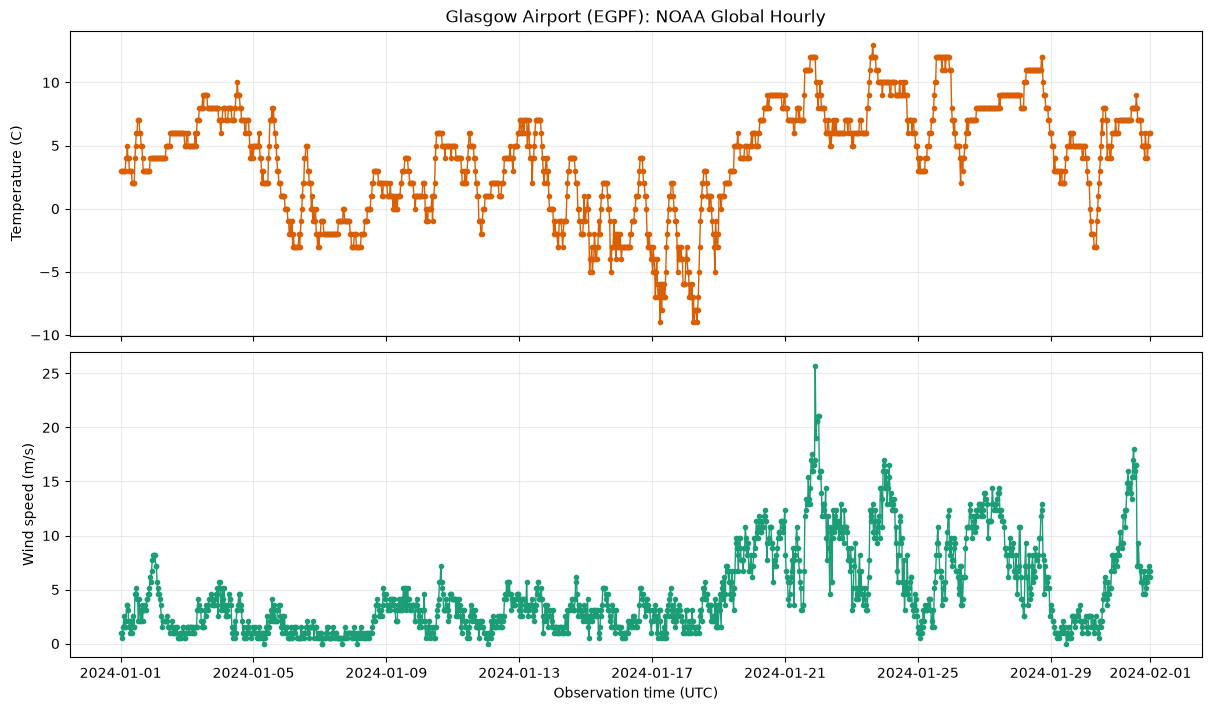

In [4]:
print(cleaned[['temperature_c', 'dew_point_c', 'wind_speed_mps']].describe())
plot_weather(cleaned, station_name=station_name)

## Forecasting temperature with a simple LSTM

Interpolate short gaps in the temperature series, normalize it, and build sliding-window
sequences. The last 20% of the series (chronologically) is held out as a test set so we can
evaluate one-step-ahead forecasts on unseen data.


In [5]:
lookback = 24
test_fraction = 0.2

temperature = cleaned['temperature_c'].interpolate(limit_direction='both')
mean, std = temperature.mean(), temperature.std()
normalized = (temperature - mean) / std

X, y = make_supervised_sequences(normalized.to_numpy(), lookback=lookback)
sequence_dates = cleaned['DATE'].to_numpy()[lookback:]

split = int(len(X) * (1 - test_fraction))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = sequence_dates[split:]

print(f'Train sequences: {len(X_train)}, test sequences: {len(X_test)}')


Train sequences: 1168, test sequences: 293


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Training history'}, xlabel='Epoch', ylabel='Loss'>)

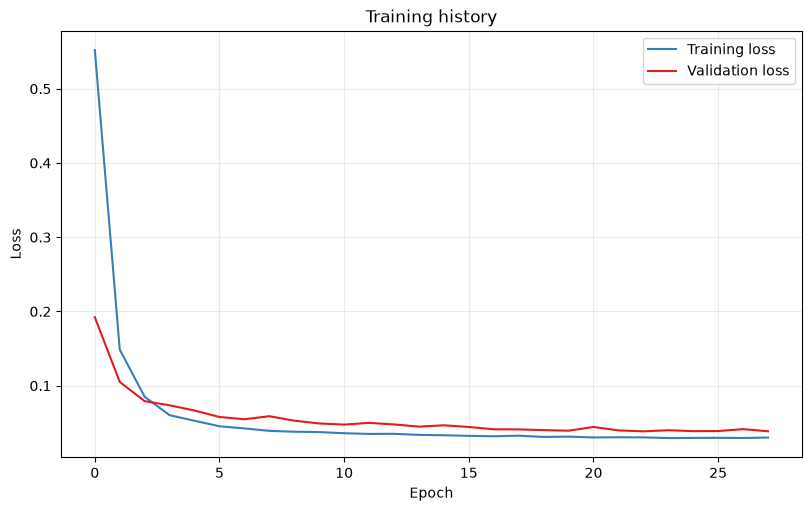

In [ ]:
model = LSTMForecaster(units=32, horizon=1)
history = train_lstm_model(model, X_train, y_train, epochs=100, batch_size=16)
plot_training_history(history)


{'mae': 0.39, 'rmse': 0.649, 'mape': 37605467.958, 'r2': 0.95}


(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Glasgow Airport (EGPF): LSTM temperature forecast'}, xlabel='Observation time (UTC)', ylabel='Value'>)

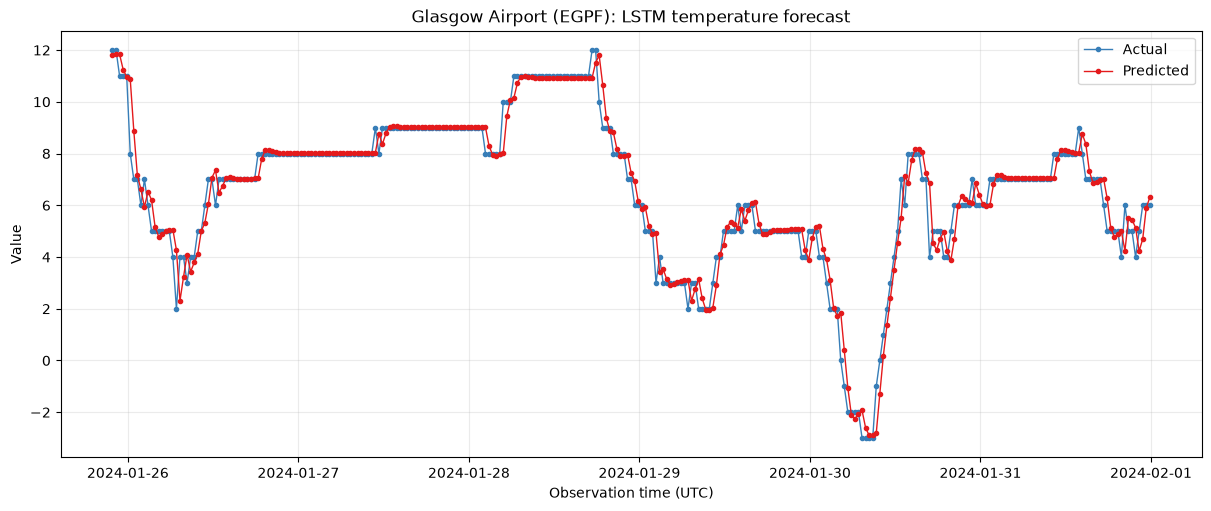

In [7]:
model.eval()
with torch.no_grad():
    predicted_norm = model(torch.as_tensor(X_test, dtype=torch.float32)).numpy()

actual = y_test.reshape(-1) * std + mean
predicted = predicted_norm.reshape(-1) * std + mean

metrics = evaluate_forecast(actual, predicted)
print({key: round(value, 3) for key, value in metrics.items()})

plot_predictions(actual, predicted, dates=dates_test, title=f'{station_name}: LSTM temperature forecast')
